# Análise de Dados com Python

### Desafio:

Você trabalha em uma empresa do varejo e tem milhares de clientes diferentes.

Com o objetivo de aumentar o faturamento e o lucro da sua empresa, a diretoria quer conseguir identificar quem é o cliente ideal para seus produtos, baseado no histórico de compras dos clientes.

Para isso, ela fez um trabalho de classificar os clientes com uma nota de 1 a 100. Só que agora, sobrou para você conseguir, a partir dessa nota, descobrir qual o perfil de cliente ideal da empresa.

Qual a profissão? Qual a idade? Qual a faixa de renda? E todas as informações que você puder analisar para dizer qual o cliente ideal da empresa.

Base de Dados: https://drive.google.com/drive/folders/1XvNLDKVH7TUS8HdH4r0TkXL__MFpoc3e?usp=share_link

In [ ]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [10]:
df_clientes = pd.read_csv('clientes.csv',
                          encoding='latin1',
                          sep=';') 
# USEI O ENCODING LATIN1 POIS O UTF-8 DEU UM PROBLEMA NA LEITURA DA BASE DE DADOS.
# DA MESMA FORMA UTILIZEI O SEPARADOR SENDO (;) POIS A BASE ESTAVA BAGUNÇADA


display(df_clientes)

,ClienteID,Origem,Idade,Salário Anual (R$),Nota (1-100),Profissão,Experiência Trabalho,Tamanho Família,Unnamed: 8
0,1,Normal,19,15000,39,Saúde,1,4,NaN
1,2,Normal,21,35000,81,Engenheiro,3,3,NaN
2,3,Promoção,20,86000,2,Engenheiro,1,1,NaN
3,4,Promoção,23,59000,73,Advogado,0,2,.
4,5,Promoção,31,38000,48,Entretenimento,2,6,NaN
...,...,...,...,...,...,...,...,...,...
1995,1996,Promoção,71,184387,48,Artista,8,7,NaN
1996,1997,Promoção,91,73158,28,Doutor,7,7,NaN
1997,1998,Normal,87,90961,14,Saúde,9,2,NaN
1998,1999,Normal,77,182109,4,Executivo,7,2,NaN


### TRATAMENTO DOS DADOS

In [3]:
# TEMOS UMA COLUNA CHAMADA "UNNAMED: 8" QUE PROVAVELMENTE TODOS OS VALORES DELA SAO NANs. COM ISSO IREI REMOVE-LA DA BASE

df_clientes = df_clientes.drop(columns="Unnamed: 8")

In [4]:
# REMOVENDO VALORES NULOS DA BASE DE DADOS
 
linhas_antes = df_clientes.shape[0]

df_clientes = df_clientes.dropna()

linhas_depois = df_clientes.shape[0]

print(f'Foram removidas {linhas_antes - linhas_depois} linhas do dataframe')

Foram removidas 35 linhas do dataframe


In [5]:
# CONFERIR E TRATAR OS TIPOS DOS DADOS

df_clientes.dtypes

# A COLUNA DE SALARIO ANUAL DEVERIA SER NUMERICA E NAO UM OBJETO
# NA COLUNA TAMBEM TEMOS VALORES "NAO INFORMADOS", QUE VOU TRANSFORMAR EM NAN
df_clientes['Salário Anual (R$)'] = pd.to_numeric(df_clientes['Salário Anual (R$)'],errors='coerce')


df_clientes.dtypes

df_clientes = df_clientes.dropna(subset=['Salário Anual (R$)'])

### ANÁLISE EXPLORATÓRIA

In [6]:
# AGORA FAREI UM FILTRO APENAS PARA CLIENTES IDEAIS, SENDO CLIENTES ESPECIALMENTE COM NOTAS DE 70+

clientes_ideais = df_clientes[df_clientes['Nota (1-100)'] >= 70]

In [7]:
# VERIFICAR SE DEU CERTO, VENDO O VALOR MÍNIMO DA NOTA

clientes_ideais['Nota (1-100)'].describe()

count    606.000000
mean      86.597360
std        9.655877
min       70.000000
25%       78.250000
50%       86.500000
75%       96.000000
max      100.000000
Name: Nota (1-100), dtype: float64

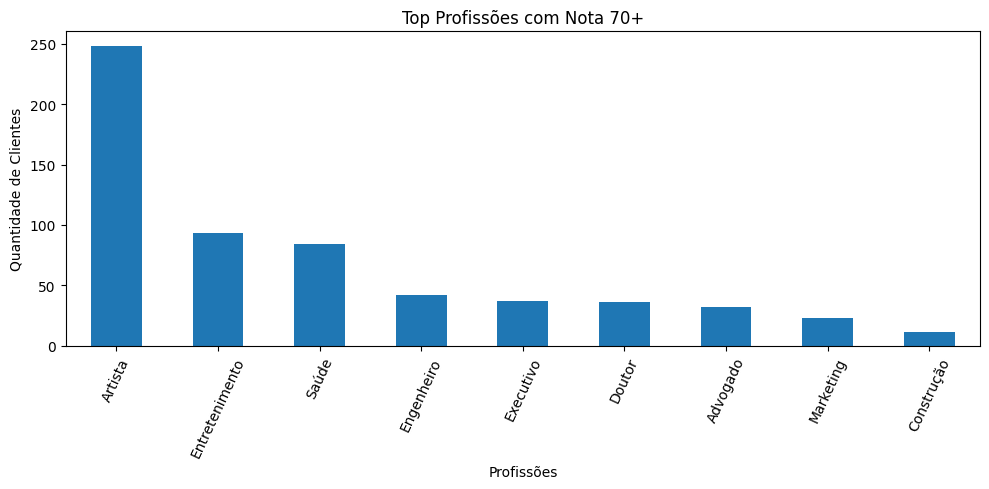

In [8]:
# GRÁFICO COM AS PROFISSÕES DOS CLIENTES IDEAIS

profissoes = clientes_ideais['Profissão'].value_counts()

plt.figure(figsize=(10,5))
profissoes.plot(kind='bar')
plt.title('Top Profissões com Nota 70+')
plt.xlabel('Profissões')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()


#### PROFISSÕES LIGADAS A ARTISTAS SEGUINDO DE ENTRETENIMENTO SÃO PREDOMINANTES

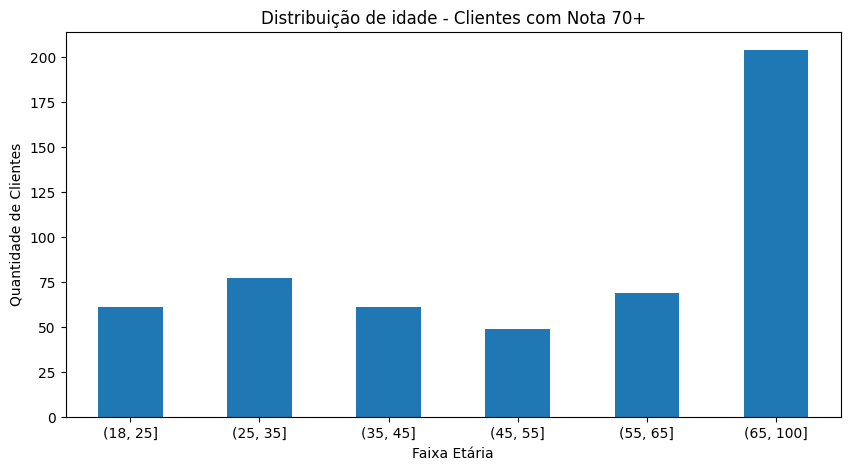

In [9]:
# GRÁFICO COM A FAIXA ETÁRIA DOS CLIENTES IDEAIS

faixa_idade = pd.cut(clientes_ideais['Idade'],
                     bins=[18,25,35,45,55,65,100]).value_counts().sort_index()

plt.figure(figsize=(10,5))
faixa_idade.plot(kind='bar')
plt.title('Distribuição de idade - Clientes com Nota 70+')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=0)
plt.show()

#### CLIENTES COM SCORE ACIMA DE 70 CONCENTRAM-SE MAJORITARIAMENTE ENTRE 65+ ANOS 

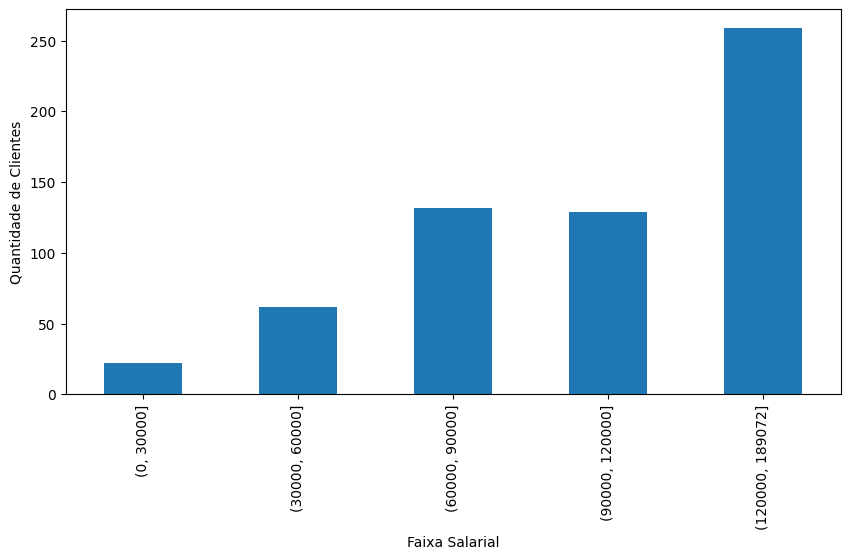

In [10]:
# FAIXA DE RENDA 

faixa_salario = pd.cut(clientes_ideais['Salário Anual (R$)'],
                        bins=[0,30000,60000,90000,120000,clientes_ideais['Salário Anual (R$)'].max()]).value_counts().sort_index()

plt.figure(figsize=(10,5))
faixa_salario.plot(kind='bar')
plt.xlabel('Faixa Salarial')
plt.ylabel('Quantidade de Clientes')
plt.show()

#### A MAIOR PARTE POSSUI RENDA ANUAL ACIMA DE 120 MIL+ 

### FINALIZAÇÃO DO PROJETO

In [11]:
filtro_profissao = clientes_ideais['Profissão'].str.contains('Artista|Entretenimento',
                                                                     case=False,
                                                                     na=False)


clientes_ideais = clientes_ideais[(clientes_ideais['Idade'] >= 65) &
                                  (clientes_ideais['Salário Anual (R$)']>= 120000) &
                                  (filtro_profissao)]

In [12]:
clientes_ideais.shape
clientes_ideais[['Idade','Salário Anual (R$)','Profissão','Nota (1-100)']].describe()
clientes_ideais['Profissão'].value_counts()

Profissão
Artista           30
Entretenimento    20
Name: count, dtype: int64

In [13]:
display(clientes_ideais)

,ClienteID,Origem,Idade,Salário Anual (R$),Nota (1-100),Profissão,Experiência Trabalho,Tamanho Família
286,287,Promoção,85,140000,92,Entretenimento,1,1
300,301,Normal,85,153787,100,Entretenimento,3,3
340,341,Promoção,84,173185,100,Artista,3,1
341,342,Normal,75,142034,94,Entretenimento,1,4
349,350,Promoção,88,166107,100,Artista,13,4
378,379,Promoção,82,180288,85,Artista,2,2
384,385,Promoção,79,143560,91,Artista,1,3
385,386,Normal,83,131574,100,Artista,1,2
394,395,Promoção,75,151696,97,Artista,15,1
462,463,Normal,93,120597,100,Artista,2,4
